# Import Libraries

In [392]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [393]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [394]:
df=pd.read_csv('actual-government-revenues-and-expenditures-by-sector.csv',sep=';')
df


,Date,Revenue/Expenditure,Sector,Value in Million Saudi Riyals
0,2016,Revenues,Non-oil Revenues,"185,749.00"
1,2016,Expenditures,Economic Resources,"38,504.00"
2,2016,Expenditures,Military,"206,467.00"
3,2016,Expenditures,Public Administration,"26,949.00"
4,2017,Revenues,Non-oil Revenues,"255,605.00"
...,...,...,...,...
135,2024,Revenues,Oil Revenues,"756,623.95"
136,2024,Expenditures,Infrastructure and Transport,"44,143.34"
137,2025,Revenues,Total Revenues,"1,111,826.37"
138,2025,Expenditures,Education,"212,464.35"


# Data Understanding
In this section, we explore the dataset to understand its structure, variables, data types, and overall quality before starting the analysis.

In [395]:
df.head(10)

,Date,Revenue/Expenditure,Sector,Value in Million Saudi Riyals
0,2016,Revenues,Non-oil Revenues,"185,749.00"
1,2016,Expenditures,Economic Resources,"38,504.00"
2,2016,Expenditures,Military,"206,467.00"
3,2016,Expenditures,Public Administration,"26,949.00"
4,2017,Revenues,Non-oil Revenues,"255,605.00"
5,2017,Expenditures,Municipality Service,"54,929.00"
6,2018,Revenues,Oil Revenues,"611,239.00"
7,2018,Expenditures,Health & Social Development,"175,487.00"
8,2018,Expenditures,Infrastructure and Transport,"48,596.00"
9,2018,Expenditures,Municipality Service,"45,924.00"


In [396]:
df.describe(exclude='number')

,Revenue/Expenditure,Sector
count,140,140
unique,2,14
top,Expenditures,Non-oil Revenues
freq,110,10


In [397]:
df.Date.unique()

array([2016, 2017, 2018, 2019, 2020, 2021, 2023, 2024, 2025, 2022])

In [398]:
len(df.Sector.unique())

14

In [399]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           140 non-null    int64  
 1   Revenue/Expenditure            140 non-null    object 
 2   Sector                         140 non-null    object 
 3   Value in Million Saudi Riyals  140 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.5+ KB


In [400]:
df.shape

(140, 4)

In [401]:
df.describe()

,Date,Value in Million Saudi Riyals
count,140.00,140.00
mean,"2,020.50","286,864.96"
std,2.88,"368,032.93"
min,"2,016.00","-311,065.00"
25%,"2,018.00","58,419.89"
50%,"2,020.50","180,618.00"
75%,"2,023.00","342,470.50"
max,"2,025.00","1,388,431.64"


In [402]:
df["Sector"].unique() 

array(['Non-oil Revenues', 'Economic Resources', 'Military',
       'Public Administration', 'Municipality Service', 'Oil Revenues',
       'Health & Social Development', 'Infrastructure and Transport',
       'Total Revenues', 'Total Expenditure',
       'Deficit / Surplus ( Expected )', 'Education', 'General Items',
       'Security and Regional Administration'], dtype=object)

In [403]:
df["Revenue/Expenditure"].value_counts()

Revenue/Expenditure
Expenditures    110
Revenues         30
Name: count, dtype: int64

# Data Quality Assessment

In [404]:
df.isnull().sum()

Date                             0
Revenue/Expenditure              0
Sector                           0
Value in Million Saudi Riyals    0
dtype: int64

In [405]:
df.duplicated().sum()

np.int64(0)

In [406]:
df.rename(columns={'Value in Million Saudi Riyals':'Value_in_Million_Saudi_Riyals'},inplace=True)

# Data Validation

In [407]:
df.groupby('Date')['Sector'].nunique()  

Date
2016    14
2017    14
2018    14
2019    14
2020    14
2021    14
2022    14
2023    14
2024    14
2025    14
Name: Sector, dtype: int64

# Business Validation

In [408]:
pivot=df.pivot_table(columns='Sector',index='Date',values='Value_in_Million_Saudi_Riyals',aggfunc="sum")[['Non-oil Revenues','Oil Revenues','Total Revenues','Total Expenditure','Deficit / Surplus ( Expected )']].copy()

In [409]:
pivot

Sector,Non-oil Revenues,Oil Revenues,Total Revenues,Total Expenditure,Deficit / Surplus ( Expected )
Date,,,,,
2016,"185,749.00","333,699.00","519,448.00","830,513.00","-311,065.00"
2017,"255,605.00","435,900.00","691,505.00","929,997.00","-238,492.00"
2018,"294,370.00","611,239.00","905,609.00","1,079,467.00","-173,858.00"
2019,"332,422.00","594,424.00","926,846.00","1,059,444.93","-132,598.93"
2020,"368,785.00","413,049.00","781,834.00","1,075,734.35","-293,900.35"
2021,"403,295.00","562,191.00","965,486.00","1,038,933.08","-73,447.08"
2022,"410,891.39","857,271.76","1,268,164.00","1,164,309.00","103,855.15"
2023,"457,727.83","754,561.77","1,212,289.60","1,293,236.09","-80,946.49"
2024,"502,471.49","756,623.95","1,259,095.44","1,374,720.25","-115,624.81"


In [410]:
pivot["Oil Revenue %"] = (
    pivot["Oil Revenues"] /
    pivot["Total Revenues"]
) * 100

pivot["Non-oil Revenue %"] = (
    pivot["Non-oil Revenues"] /
    pivot["Total Revenues"]
) * 100
pivot

Sector,Non-oil Revenues,Oil Revenues,Total Revenues,Total Expenditure,Deficit / Surplus ( Expected ),Oil Revenue %,Non-oil Revenue %
Date,,,,,,,
2016,"185,749.00","333,699.00","519,448.00","830,513.00","-311,065.00",64.24,35.76
2017,"255,605.00","435,900.00","691,505.00","929,997.00","-238,492.00",63.04,36.96
2018,"294,370.00","611,239.00","905,609.00","1,079,467.00","-173,858.00",67.49,32.51
2019,"332,422.00","594,424.00","926,846.00","1,059,444.93","-132,598.93",64.13,35.87
2020,"368,785.00","413,049.00","781,834.00","1,075,734.35","-293,900.35",52.83,47.17
2021,"403,295.00","562,191.00","965,486.00","1,038,933.08","-73,447.08",58.23,41.77
2022,"410,891.39","857,271.76","1,268,164.00","1,164,309.00","103,855.15",67.60,32.40
2023,"457,727.83","754,561.77","1,212,289.60","1,293,236.09","-80,946.49",62.24,37.76
2024,"502,471.49","756,623.95","1,259,095.44","1,374,720.25","-115,624.81",60.09,39.91


# EDA

## Budget Balance

In [411]:
Deficit_Surplus=pivot['Deficit / Surplus ( Expected )']
Deficit_Surplus

Date
2016   -311,065.00
2017   -238,492.00
2018   -173,858.00
2019   -132,598.93
2020   -293,900.35
2021    -73,447.08
2022    103,855.15
2023    -80,946.49
2024   -115,624.81
2025   -276,605.27
Name: Deficit / Surplus ( Expected ), dtype: float64

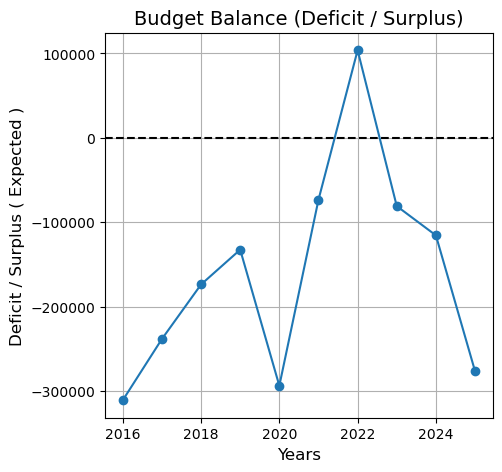

In [452]:
plt.figure(figsize=(5,5))
Deficit_Surplus.plot(kind='line',marker='o')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Years',fontsize=12)
plt.ylabel('Deficit / Surplus ( Expected )',fontsize=12)
plt.title('Budget Balance (Deficit / Surplus)',fontsize=14)
plt.grid()
plt.savefig('Budget_Balance_Deficit_Surplus.jpg',bbox_inches="tight")
plt.show()

In [413]:
Revenues_Expenditures=pivot[['Total Revenues','Total Expenditure']]
Revenues_Expenditures

Sector,Total Revenues,Total Expenditure
Date,,
2016,"519,448.00","830,513.00"
2017,"691,505.00","929,997.00"
2018,"905,609.00","1,079,467.00"
2019,"926,846.00","1,059,444.93"
2020,"781,834.00","1,075,734.35"
2021,"965,486.00","1,038,933.08"
2022,"1,268,164.00","1,164,309.00"
2023,"1,212,289.60","1,293,236.09"
2024,"1,259,095.44","1,374,720.25"


<Figure size 500x500 with 0 Axes>

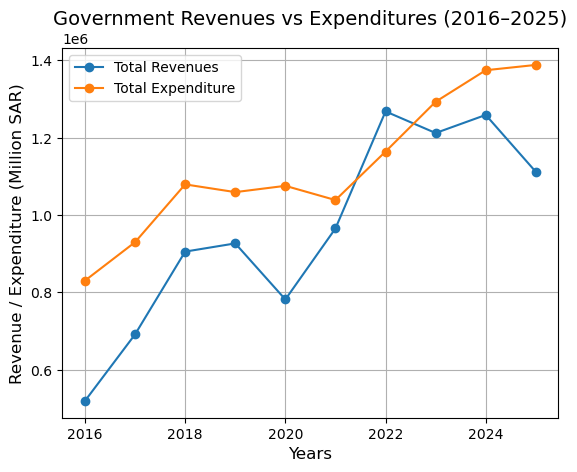

In [451]:
plt.figure(figsize=(5,5))
Revenues_Expenditures.plot(kind='line',marker='o')
plt.xlabel('Years',fontsize=12)
plt.ylabel('Revenue / Expenditure (Million SAR)',fontsize=12)
plt.title('Government Revenues vs Expenditures (2016–2025)',fontsize=14)
plt.grid()
plt.legend()
plt.savefig('Government Revenues vs Expenditures (2016–2025).jpg',bbox_inches="tight")
plt.show()

## Revenue Composition

In [415]:
revenue_composition=pivot[['Non-oil Revenues','Oil Revenues']]
revenue_composition

Sector,Non-oil Revenues,Oil Revenues
Date,,
2016,"185,749.00","333,699.00"
2017,"255,605.00","435,900.00"
2018,"294,370.00","611,239.00"
2019,"332,422.00","594,424.00"
2020,"368,785.00","413,049.00"
2021,"403,295.00","562,191.00"
2022,"410,891.39","857,271.76"
2023,"457,727.83","754,561.77"
2024,"502,471.49","756,623.95"


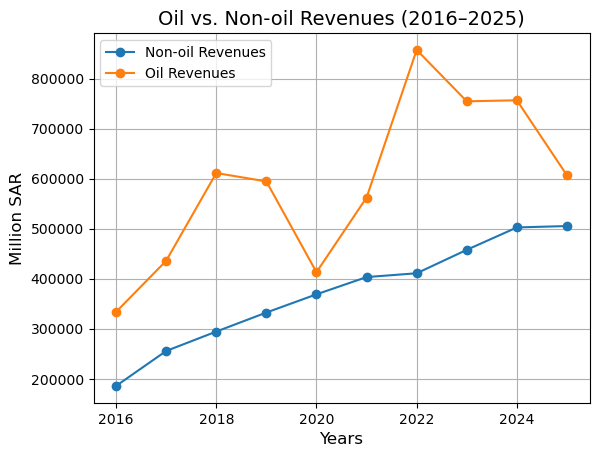

In [445]:
revenue_composition.plot(kind='line',marker='o')
plt.xlabel('Years',fontsize=12)
plt.ylabel('Million SAR',fontsize=12)
plt.title('Oil vs. Non-oil Revenues (2016–2025)',fontsize=14)
plt.grid()
plt.legend()
plt.savefig('Oil vs Non-oil Revenues (2016–2025).jpg',bbox_inches="tight")
plt.show()

In [417]:
revenue_composition_p=pivot[['Oil Revenue %','Non-oil Revenue %']]
revenue_composition_p

Sector,Oil Revenue %,Non-oil Revenue %
Date,,
2016,64.24,35.76
2017,63.04,36.96
2018,67.49,32.51
2019,64.13,35.87
2020,52.83,47.17
2021,58.23,41.77
2022,67.60,32.40
2023,62.24,37.76
2024,60.09,39.91


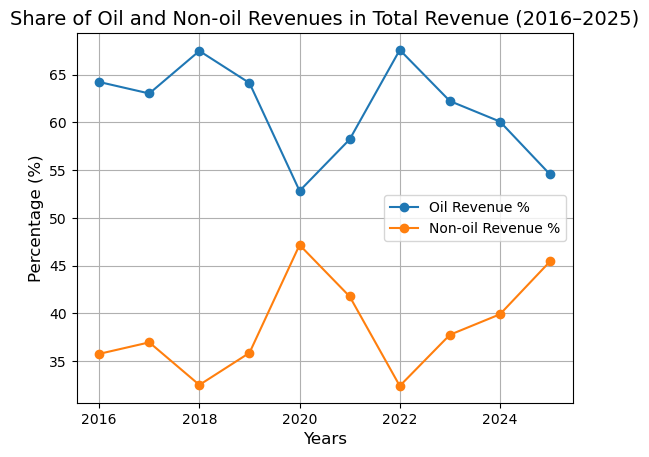

In [446]:
revenue_composition_p.plot(kind='line',marker='o')
plt.xlabel('Years',fontsize=12)
plt.ylabel('Percentage (%)',fontsize=12)
plt.title('Share of Oil and Non-oil Revenues in Total Revenue (2016–2025)',fontsize=14)
plt.grid()
plt.legend()
plt.savefig('Share of Oil and Non-oil Revenues in Total Revenue (2016–2025).jpg',bbox_inches="tight")
plt.show()

## Expenditure by Sector

In [419]:
expenditure=df.pivot_table(columns='Sector',index='Date',values='Value_in_Million_Saudi_Riyals',aggfunc="sum")[['Economic Resources',
    'Military',
    'Public Administration',
    'Municipality Service',
    'Health & Social Development',
    'Infrastructure and Transport',
    'Education',
    'General Items',
    'Security and Regional Administration']].sum().sort_values(ascending=True)

expenditure

Sector
Public Administration                    389,741.10
Infrastructure and Transport             459,209.07
Municipality Service                     622,958.02
Economic Resources                       764,371.56
Security and Regional Administration   1,141,677.32
General Items                          1,524,199.04
Health & Social Development            2,024,040.97
Education                              2,050,191.48
Military                               2,258,396.77
dtype: float64

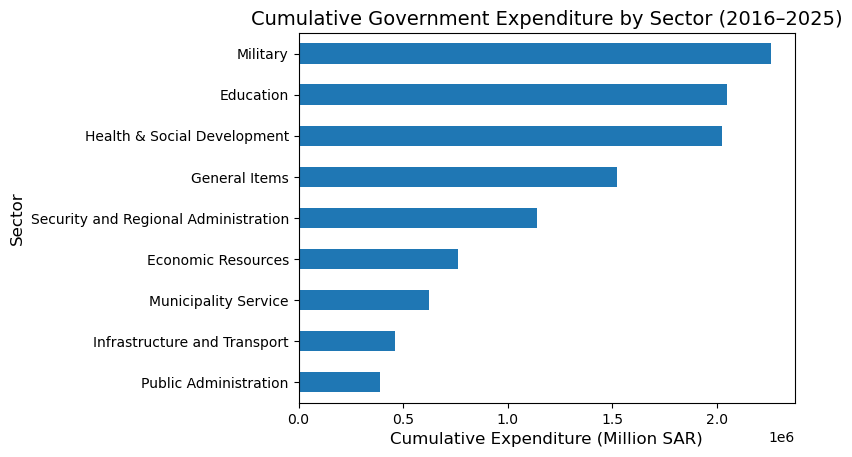

In [450]:
expenditure.plot(kind='barh')
plt.ylabel('Sector',fontsize=12)
plt.xlabel('Cumulative Expenditure (Million SAR)',fontsize=12)
plt.title('Cumulative Government Expenditure by Sector (2016–2025)',fontsize=14)
plt.savefig('Total Expenditure by Sector.jpg',bbox_inches="tight")
plt.show()